In [1]:
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
mrl_isoform = np.load( path + 'mrl_isoform_resolved.npz')

In [3]:
investigate_dataset(mrl_isoform)

['X', 'y', 'genes']

Array shapes:


X shape: (11693, 12288, 6)
y shape: (11693,)
genes shape: (11693,)

First few y values: [5.40141546 3.33709259 5.41937329 5.74227841 5.32184319]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [1. 0. 0. 0. 0.]


In [4]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(mrl_isoform['X'], mrl_isoform['genes'], n_components=1024)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (11693, 1024)


In [5]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 54.74%


In [6]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, mrl_isoform['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,-0.760618,0.389354,0.407200,0.013840,-0.543954,0.271856,0.509241,-1.189382,0.450743,-0.392808
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,-0.678451,-0.620431,-0.556618,-0.015055,0.573693,-1.038760,-0.290563,-0.623669,0.145572,-1.074818
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.126578,0.664627,0.787514,-0.750808,0.001948,-0.275051,-0.295227,0.907576,-0.498445,0.930653
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,-0.583220,-0.022933,-0.731019,0.692012,-0.183101,-0.038755,0.428053,-0.146997,-0.816452,-0.210615
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-1.039102,0.544033,0.922958,-0.687363,-0.671742,-0.336319,0.786180,-0.306712,0.563094,0.514492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,-0.291936,-0.489119,-0.036328,-0.320304,-0.419473,-0.093135,-0.248898,0.144297,-0.406303,0.036897
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579755,...,-1.389038,2.363158,-1.111383,-1.407954,3.305431,2.237561,-0.026986,-1.196171,0.527420,-1.606036
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,-0.643971,-0.168956,0.087856,-0.350901,0.716879,-0.064056,-0.313758,0.298393,-0.035048,-0.222129


In [7]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [8]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,-0.760618,0.389354,0.407200,0.013840,-0.543954,0.271856,0.509241,-1.189382,0.450743,-0.392808
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,-0.678451,-0.620431,-0.556618,-0.015055,0.573693,-1.038760,-0.290563,-0.623669,0.145572,-1.074818
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.126578,0.664627,0.787514,-0.750808,0.001948,-0.275051,-0.295227,0.907576,-0.498445,0.930653
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,-0.583220,-0.022933,-0.731019,0.692012,-0.183101,-0.038755,0.428053,-0.146997,-0.816452,-0.210615
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-1.039102,0.544033,0.922958,-0.687363,-0.671742,-0.336319,0.786180,-0.306712,0.563094,0.514492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,-0.291936,-0.489119,-0.036328,-0.320304,-0.419473,-0.093135,-0.248898,0.144297,-0.406303,0.036897
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579755,...,-1.389038,2.363158,-1.111383,-1.407954,3.305431,2.237561,-0.026986,-1.196171,0.527420,-1.606036
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,-0.643971,-0.168956,0.087856,-0.350901,0.716879,-0.064056,-0.313758,0.298393,-0.035048,-0.222129


In [9]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,-0.543954,0.271856,0.509241,-1.189382,0.450743,-0.392808,False,False,False,False
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,0.573693,-1.038760,-0.290563,-0.623669,0.145572,-1.074818,False,False,False,False
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.001948,-0.275051,-0.295227,0.907576,-0.498445,0.930653,False,False,False,False
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,-0.183101,-0.038755,0.428053,-0.146997,-0.816452,-0.210615,False,False,False,False
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-0.671742,-0.336319,0.786180,-0.306712,0.563094,0.514492,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SCO2,-11.021691,-8.526528,-5.202515,-2.475116,-1.106725,-2.811286,7.074593,0.870503,3.028499,-0.628025,...,0.185484,-0.211445,0.043314,-0.440746,-0.247672,-0.095842,False,False,False,False
TBCE,-3.199916,-0.195192,13.523295,6.196819,-5.897826,-0.775914,0.624610,1.177227,2.232309,3.613913,...,0.766941,0.177968,-0.551211,-0.218997,0.672234,0.443252,False,False,False,False
ABCF2,16.090095,17.135822,-9.145933,4.259971,6.373613,1.688988,-0.188709,2.161776,3.379265,-0.509944,...,0.107264,-1.452661,0.803104,-0.696640,-0.526161,0.391049,False,True,False,False


## Predict NCG_Known_Cancer_Gene

In [10]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    5610
True      331
Name: count, dtype: int64

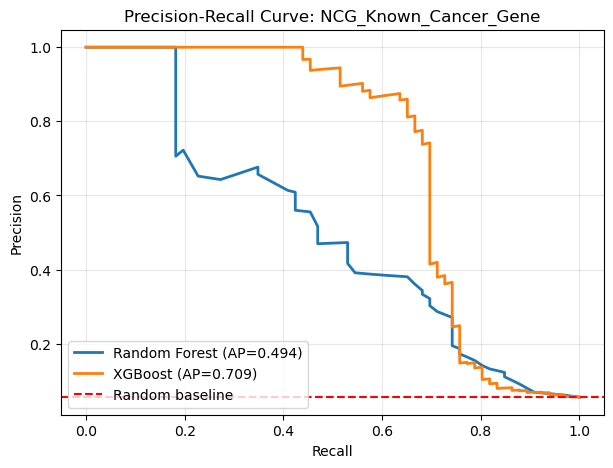

In [11]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [12]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    5450
True      491
Name: count, dtype: int64

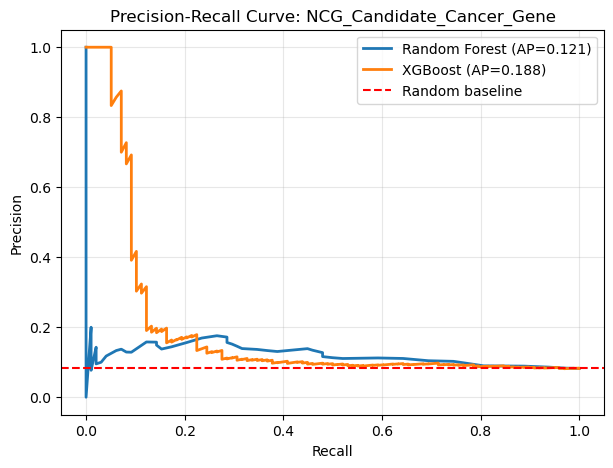

In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [14]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    5675
True      266
Name: count, dtype: int64

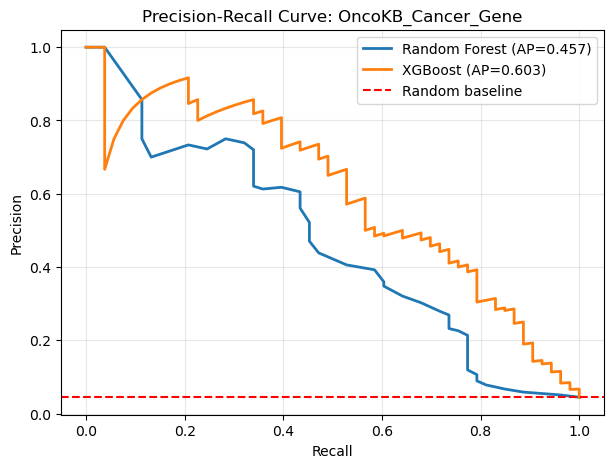

In [15]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [16]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    5788
True      153
Name: count, dtype: int64

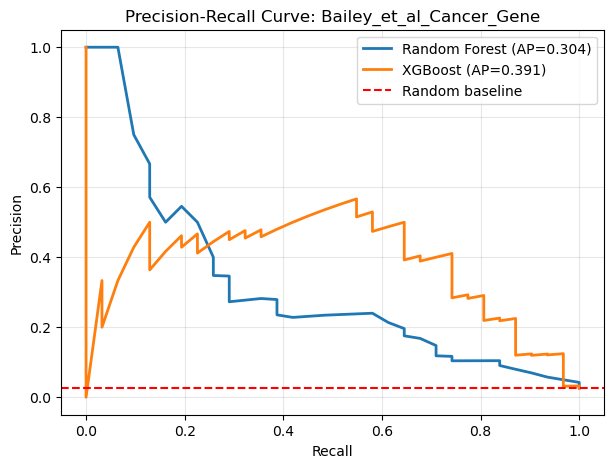

In [17]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')